In [1]:
#Instalar librerias
!pip install dtreeviz
!pip install catboost
!pip install shap
!pip install xgboost
!pip install optbinning
!pip install lightgbm

In [2]:
#Importo librerias necesarias para el proceso de EDA (Esploratory Data Analysis)
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import folium
import numpy as np
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go

#Importo librerias necesarias para el proceso de Feature engineering y evaluación de modelos
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import GridSearchCV

#Importo librerias necesarias para ML
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import shap
from sklearn.tree import export_graphviz
import graphviz
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)


In [3]:
# obtener desde GitHub
red = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/main/datasets/Wine_Quality/winequality-red%5B1%5D.csv"
white = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/main/datasets/Wine_Quality/winequality-white%5B1%5D.csv"

# Cargar los datos
df_red = pd.read_csv(red, sep=';')
df_white = pd.read_csv(white, sep=';')

# Combinar ambos datasets
df = pd.concat([df_red, df_white], ignore_index=True)

# Mostrar las primeras filas
print(df.head())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [4]:
#No queremos incluir la variable quality dentro del tratamiento de outliers
df_outliers = df.drop(columns='quality')
df_target= df['quality']



Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

for col in df_outliers.columns:
    col_outliers = ((df_outliers[col] < (Q1[col] - 3 * IQR[col])) | (df_outliers[col] > (Q3[col] + 3 * IQR[col]))) # se detectan outliers usando el rango interquartil
    df_outliers.loc[col_outliers, col] = df_outliers[col].median() #Los reemplzamos con la mediana

df_target_b= df['quality'].apply(lambda x: 1 if x >= 7 else 0)

#Juntamos el dataset limpio con el nuevo target
df_limpio = df_outliers.copy()
df_limpio['quality'] = df_target_b
df_limpio.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [5]:
# División de datos en entrenamiento y test
X = df_limpio.drop(['quality'], axis=1)
y = df_limpio['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Usaremos division 80-20 por la cantidad de datos, lo usual en datasets más grandes es 70-30


In [6]:
# Base learners
estimators = [
    ('lgbm', LGBMClassifier(n_estimators=300,learning_rate=0.1,max_depth=15,num_leaves=50,subsample=0.8,colsample_bytree=0.8,random_state=42,verbose=0)),
    ('bag', BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=200,max_features=0.6,max_samples=0.8,bootstrap=True,random_state=42,verbose=0)),
    ('rf', RandomForestClassifier(n_estimators=250,max_depth=20,min_samples_split=5,min_samples_leaf=2,max_features='sqrt',random_state=42,verbose=0)),
    ('xgb', XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,subsample=0.8,colsample_bytree=0.8,use_label_encoder=False,eval_metric='logloss',random_state=42,verbose=0)),
]

# Weighted Voting (soft + pesos)
weights = [1, 0.5, 0.5, 0.5]  # ajustar según desempeño individual
voting_weighted = VotingClassifier(estimators=estimators, voting='soft', weights=weights)
voting_weighted.fit(X_train, y_train)
weighted_pred = voting_weighted.predict(X_test)
print(f"Weighted Voting Accuracy: {accuracy_score(y_test, weighted_pred):.3f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Weighted Voting Accuracy: 0.892


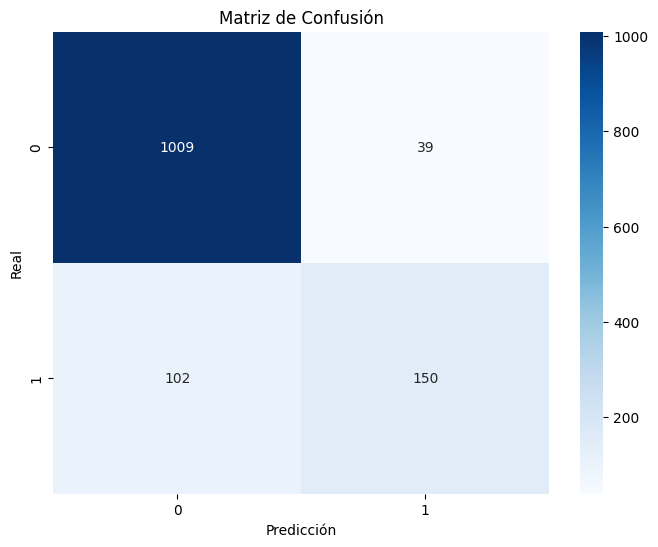

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1048
           1       0.79      0.60      0.68       252

    accuracy                           0.89      1300
   macro avg       0.85      0.78      0.81      1300
weighted avg       0.89      0.89      0.89      1300



In [7]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, weighted_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, weighted_pred))

#curva ROC
y_probs = voting_weighted.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

In [8]:
import joblib
# Guardar modelo entrenado para poderlo usar nuevamente sin necesidad de volverlo a entrenar
joblib.dump(voting_weighted, "modelo_vino.pkl")

['modelo_vino.pkl']

In [9]:
!pip install streamlit

In [10]:
!pip install pyngrok

In [11]:
from pyngrok import ngrok
ngrok.set_auth_token("304H6US24qKSn2BPVs8Zwywoyex_5k8az8SAkSf2Ch5ZURVbz")


In [13]:

# Autenticación con ngrok
ngrok.set_auth_token("304H6US24qKSn2BPVs8Zwywoyex_5k8az8SAkSf2Ch5ZURVbz")

In [18]:
#Instalar dependencias
!pip install streamlit pyngrok scikit-learn pandas joblib

#Crear archivo de la app Streamlit
app_code = '''
import streamlit as st
import numpy as np
import joblib

st.set_page_config(page_title="Calidad de Vino", layout="centered")
st.title("Predicción de Calidad de Vino")

features = ['fixed acidity','volatile acidity','citric acid','residual sugar','chlorides',
            'free sulfur dioxide','total sulfur dioxide','density','pH','sulphates','alcohol']
inputs = []

for feature in features:
    value = st.number_input(f"{feature}", min_value=0.0, format="%.3f")
    inputs.append(value)

try:
    model = joblib.load("modelo_vino.pkl")
except:
    st.error("No se encontró el archivo 'modelo_vino.pkl'. Sube el modelo entrenado.")

if st.button("Predecir"):
    datos = np.array(inputs).reshape(1, -1)
    pred = model.predict(datos)[0]
    prob = model.predict_proba(datos)[0][1]

    if pred == 1:
        st.success(f"Vino de alta calidad (probabilidad: {prob:.2f})")
    else:
        st.warning(f"Vino de calidad estándar (probabilidad: {prob:.2f})")
'''

with open("app.py", "w") as f:
    f.write(app_code)


In [19]:
from pyngrok import ngrok
import os

# Ejecutar Streamlit en segundo plano
os.system("streamlit run app.py &")

# Crear túnel público
public_url = ngrok.connect(8501)
print("Tu app está disponible en:", public_url)


Tu app está disponible en: NgrokTunnel: "https://e52875bcb18c.ngrok-free.app" -> "http://localhost:8501"


App streamlit

In [17]:
# app.py
import streamlit as st
import numpy as np
import joblib

# Cargar modelo
model = joblib.load("modelo_vino.pkl")

st.title("Predicción de Calidad de Vino ")

# Inputs del usuario
inputs = []
features = ['fixed acidity','volatile acidity','citric acid','residual sugar','chlorides',
            'free sulfur dioxide','total sulfur dioxide','density','pH','sulphates','alcohol']

for feature in features:
    value = st.number_input(f"{feature}", min_value=0.0, format="%.3f")
    inputs.append(value)

# Predicción
if st.button("Predecir"):
    datos = np.array(inputs).reshape(1, -1)
    pred = model.predict(datos)[0]
    prob = model.predict_proba(datos)[0][1]

    if pred == 1:
        st.success(f"Vino de alta calidad (probabilidad: {prob:.2f})")
    else:
        st.warning(f"Vino de calidad estándar (probabilidad: {prob:.2f})")

2025-09-26 01:36:49.924 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-26 01:36:51.085 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-09-26 01:36:51.088 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-26 01:36:51.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-26 01:36:51.093 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-26 01:36:51.095 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-26 01:36:51.097 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-26 01:36:51.098 Thread 'MainThread': mi